# Reading profiles

An image-based profiling pipeline hands you a table: one row per well or per cell, a few hundred columns of
CellProfiler measurements, and some metadata columns mixed in among them.
{func}`~mantispy.io.read_profiles` turns one or many of those tables into an {class}`~anndata.AnnData`.
It splits the measurements from the metadata and annotates what each feature name encodes.

In [1]:
import mantispy as mt

## A dataset

{mod}`mantispy.ds` downloads whole accessions from the
[Cell Painting Gallery](https://github.com/broadinstitute/cellpainting-gallery), so there is something real to
read.
This one is kinase inhibitors at a range of doses, eight plates of it.

In [2]:
adata = mt.ds.pki()
adata

/Users/tim.treis/Documents/GitHub/mantispy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 3072 × 5857
    obs: 'Metadata_plate_map_name', 'Metadata_broad_sample', 'Metadata_mg_per_ml', 'Metadata_mmoles_per_liter', 'Metadata_solvent', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_Barcode', 'Metadata_Supplier', 'Metadata_Supplier_Catalog', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_CellCount', 'Metadata_Control', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

Numeric columns that parse as CellProfiler features became the feature matrix, and everything else became `obs`.
Every metadata prefix is normalized to `Metadata_`, and the loader adds the columns an analysis looks for:
`Metadata_Compound`, `Metadata_Concentration`, `Metadata_Control` and `Metadata_Perturbation`.

In [3]:
adata.obs.head()

,Metadata_plate_map_name,Metadata_broad_sample,Metadata_mg_per_ml,Metadata_mmoles_per_liter,Metadata_solvent,Metadata_Plate,Metadata_Well,Metadata_Site_Count,Metadata_Count_CellsIncludingEdges,Metadata_Count_Cytoplasm,...,Metadata_Supplier,Metadata_Supplier_Catalog,Metadata_pert_type,Metadata_control_type,Metadata_CellCount,Metadata_Control,Metadata_Compound,Metadata_Concentration,Metadata_MOA,Metadata_Perturbation
0,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A01,9,1890,1758,...,NaN,DMSO,control,negcon,1758.0,True,DMSO,NaN,NaN,DMSO
1,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A02,9,2137,1941,...,NaN,DMSO,control,negcon,1941.0,True,DMSO,NaN,NaN,DMSO
2,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A03,9,2007,1840,...,NaN,DMSO,control,negcon,1840.0,True,DMSO,NaN,NaN,DMSO
3,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A04,9,2027,1869,...,NaN,DMSO,control,negcon,1869.0,True,DMSO,NaN,NaN,DMSO
4,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A05,9,2369,2165,...,NaN,DMSO,control,negcon,2165.0,True,DMSO,NaN,NaN,DMSO


Plates of one screen can disagree on their columns when a channel failed on one of them, so the eight are read
down to the features they share.
That is `on_column_mismatch="intersect"`; the default is to raise instead, so a mismatch is never silent.

In [4]:
adata.obs.groupby("Metadata_Plate", observed=True).size()

Metadata_Plate
BR00122970    384
BR00122971    384
BR00122972    384
BR00122973    384
BR00122974    384
BR00122975    384
BR00122977    384
BR00122978    384
dtype: int64

## What a feature name says

CellProfiler names a feature `<object>_<feature group>_<feature>[_<channel>][_<parameters>]`, and
{func}`~mantispy.io.read_profiles` pulls that apart into `var`.
`Correlation` features measure colocalization between a pair of channels, recorded as `DNA|RNA`.
`AreaShape` is geometry and carries none.

In [5]:
adata.var.head()

,object,feature_group,feature,channel,scale,angle,gray_levels,radial_bin,params,is_feature
Cells_AreaShape_Area,Cells,AreaShape,Area,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_BoundingBoxArea,Cells,AreaShape,BoundingBoxArea,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_BoundingBoxMaximum_X,Cells,AreaShape,BoundingBoxMaximum_X,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_BoundingBoxMaximum_Y,Cells,AreaShape,BoundingBoxMaximum_Y,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_BoundingBoxMinimum_X,Cells,AreaShape,BoundingBoxMinimum_X,NaN,NaN,NaN,NaN,NaN,NaN,True


In [6]:
adata.var.groupby(["object", "feature_group"], observed=True).size().sort_values(ascending=False).head(10)

object     feature_group     
Nuclei     Texture               1248
Cytoplasm  Texture               1248
Cells      Texture               1248
Nuclei     Correlation            224
Cytoplasm  Correlation            224
Cells      Correlation            224
           RadialDistribution     207
Cytoplasm  RadialDistribution     207
Cells      Granularity            128
Nuclei     Granularity            128
dtype: int64

A slice of the measurements is then a query on `var` instead of a regex on the names:

In [7]:
dna_intensity = adata[:, (adata.var["channel"] == "DNA") & (adata.var["feature_group"] == "Intensity")]
dna_intensity.shape

(3072, 45)

## Reading your own files

The remaining arguments cover what has differed between datasets:

```python
adata = mt.io.read_profiles(
    sorted(Path("profiles").glob("*/*.parquet")),
    sentinels=-999,                          # values standing for missing, replaced with NaN
    index_columns=("Metadata_Plate", "Metadata_Well"),  # joined with ":" into the observation index
    metadata_columns=("ImageNumber",),       # numeric columns that are not features
    path_columns={"Metadata_Batch": 2},      # metadata read off the file path
    on_column_mismatch="intersect",
)
```

`path_columns` maps a column name to how many directories up from the file to read the name of.
That is how a batch or a plate that exists only in the directory layout gets into `obs`.

Pointed at a directory instead, the same call reads a CellProfiler `ExportToSpreadsheet` run, one row per cell
with every object joined on, or the parquet parts CytoTable writes.

## A first look

These are the raw measurements, and some features failed on some wells.
Dropping those and scaling the rest is enough for a first look with scanpy:

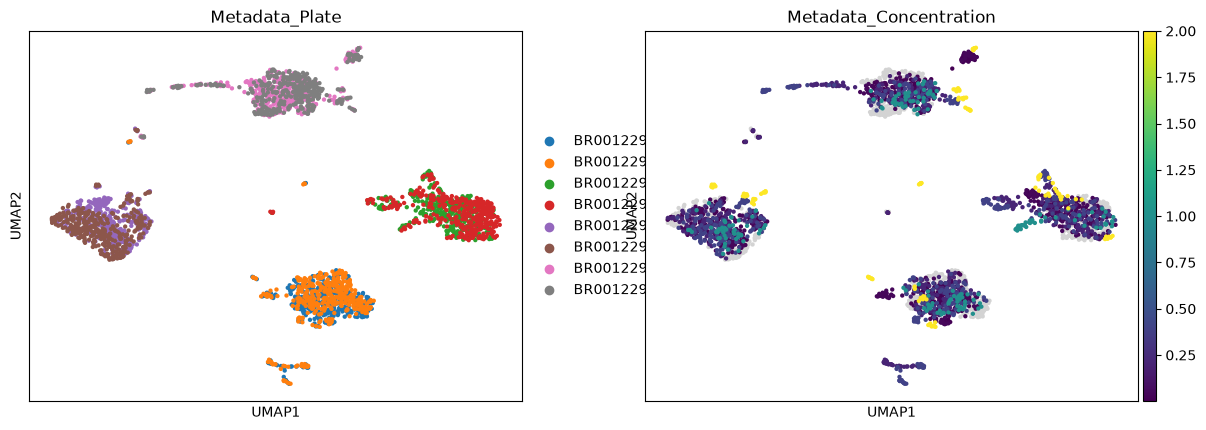

In [8]:
import scanpy as sc

mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)
sc.pp.scale(adata)

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["Metadata_Plate", "Metadata_Concentration"], ncols=2)

The plates separate.
That is a batch effect, which a real analysis has to correct before interpreting the rest of the embedding.